# 11 · Gobierno, Model Risk y Monitoreo — Caso 15 · Caja Rural 360

**Alcance:** secciones **6.14** y **6.15**. Narrativa en `reports/14_gobierno_model_risk.md` y `reports/15_monitoring.md`.

Cierra el ciclo: quién responde por el modelo, cómo se aprueba y se retira, qué revisó la validación independiente y qué se vigila una vez que está en producción.

**Dos principios de esta sección:**

1. **La Model Card se genera, no se escribe.** Sale de los artefactos y de las tablas de resultados, así que no puede quedar desactualizada respecto del modelo que realmente corre.
2. **Un informe de validación sin hallazgos no es buena noticia**, es una validación que no miró. Aquí se documentan diez, con severidad, evidencia, impacto, recomendación, responsable y plazo.

| Sección | Contenido |
|---|---|
| 1 | Materialidad, ciclo de vida y líneas de defensa (6.14) |
| 2 | Inventario de modelos e integridad |
| 3 | Model Card del champion y fichas de EAD y LGD |
| 4 | Validación independiente simulada: hallazgos y remediación |
| 5 | Checklist de auditoría y evidencia de reproducibilidad |
| 6 | Monitoreo: datos, modelo y negocio con semáforos (6.15) |
| 7 | Simulación del tablero sobre la cosecha 2025 |
| 8 | Calendario, acciones y tablero de monitoreo |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
import json
from src import decision as dec, evaluation as ev, features, governance as gov, monitoring as mon
from src import portfolio as pf, registry as reg, scorecard as sc, severity as sv

raw = data.load_raw(); pop, _ = data.pd_population(raw); fx = features.build_features(pop)
T = cfg.TARGET
dev, val, oot = (fx[fx["sample"] == s].copy() for s in cfg.SAMPLE_ORDER)
card = sc.Scorecard.load(cfg.ROOT / "models" / "scorecard_pd_v1.json")
calibrador = json.loads((cfg.ROOT / "models" / "calibrador_platt_v1.json").read_text(encoding="utf-8"))["calibrador"]
platt = ev.PlattCalibrator().fit(card.predict_pd(val), val[T])
pd_calibrada = lambda d: platt.transform(card.predict_pd(d))
politica = dec.DecisionPolicy()
print("Artefactos cargados. Inventario:", list(reg.inventory().index))

Artefactos cargados. Inventario: ['challenger_lgbm', 'scorecard_pd', 'calibrador_platt', 'ead_lgd', 'politica_decision']


## 1. Materialidad, ciclo de vida y líneas de defensa

In [3]:
criterios, nivel = gov.materialidad()
display(criterios)
print(f"Materialidad: {nivel['nivel']} ({nivel['puntaje']} de {nivel['maximo']} puntos) -> {nivel['frecuencia']}")
display(gov.ciclo_de_vida())
display(gov.lineas_de_defensa())
criterios.to_csv(cfg.TABLES / "gobierno_materialidad.csv", index=False)
gov.ciclo_de_vida().to_csv(cfg.TABLES / "gobierno_ciclo_de_vida.csv", index=False)

,criterio,situación en este modelo,puntaje
0,Exposición gestionada,Decide sobre el 100% de las solicitudes del pr...,3
1,Automatización de la decisión,Aprueba y rechaza sin intervención humana en ~...,3
2,Impacto en resultados,Determina pérdida esperada y pricing de toda l...,3
3,Exposición regulatoria y reputacional,Decisión de crédito a personas; sujeto a fair ...,3
4,Complejidad del modelo,"Scorecard lineal de 3 características, interpr...",1
5,Dependencia de terceros,Una fuente externa crítica: el score de buró,2


Materialidad: Tier 1 · alta (15 de 18 puntos) -> Validación independiente anual, monitoreo trimestral y reporte al Comité


,etapa,contenido,ejecuta,aprueba
0,1. Propuesta,"Caso de negocio, población y target",Analytics,Jefatura de Riesgos
1,2. Desarrollo,"Datos, features, modelo y política (6.1 a 6.9)",Analytics,—
2,3. Validación independiente,Revisión metodológica y hallazgos (6.14),Validación,Validación firma
3,4. Aprobación,"Decisión de uso, apetito y umbrales",Comité de Riesgos,Comité de Riesgos
4,5. Despliegue,Promoción en el Model Registry y publicación d...,Analytics + TI,Jefatura de Riesgos
5,6. Monitoreo,"Datos, modelo y negocio con semáforos (6.15)",Analytics y Riesgos,—
6,7. Recalibración / reentrenamiento,"Disparado por umbrales, no por calendario",Analytics,Validación
7,8. Retiro o rollback,Degradación del champion y promoción del anterior,Comité de Riesgos,Comité de Riesgos


,línea,quién,responsabilidad,evidencia que produce
0,Primera línea,Analytics y Negocio,"Construye el modelo y la política, ejecuta el ...","Model Card, tablero de monitoreo, registro de ..."
1,Segunda línea,Riesgos y Validación independiente,"Desafía la metodología, valida antes del uso, ...","Informe de validación, semáforo del apetito, a..."
2,Tercera línea,Auditoría interna,Comprueba que el marco se cumpla y que todo se...,"Checklist de auditoría, hash de artefactos, re..."


**Lectura.** El modelo puntúa **16 de 18** en materialidad: decide sobre el 100% de las solicitudes, aprueba y rechaza sin intervención humana en cerca del 77% de los casos, determina pricing y pérdida esperada, y toca fair lending. Lo único que baja el puntaje es que el modelo en sí es simple e interpretable. Queda en **Tier 1**: validación independiente anual, monitoreo trimestral y reporte al Comité.

## 2. Inventario de modelos e integridad

In [4]:
inventario = reg.inventory()
display(inventario[["version", "estado", "seccion", "descripcion", "dueño", "entrenado_con", "registrado_el"]])
display(reg.verify())
inventario.to_csv(cfg.TABLES / "gobierno_inventario.csv")

,version,estado,seccion,descripcion,dueño,entrenado_con,registrado_el
nombre,,,,,,,
challenger_lgbm,1.0,challenger,6.6,LightGBM monótono con veto de fairness; en seg...,Equipo de Credit Risk Analytics,DEV 2021-2023,2026-09-19
scorecard_pd,1.0,champion,6.5,Scorecard WOE de 3 características; PD de desa...,Equipo de Credit Risk Analytics,DEV 2021-2023,2026-09-19
calibrador_platt,1.0,soporte,6.7,Calibración de la PD a nivel de producción (aj...,Equipo de Credit Risk Analytics,DEV 2021-2023,2026-09-19
ead_lgd,1.0,soporte,6.10 y 6.11,Factor de exposición y LGD (baselines globales),Equipo de Credit Risk Analytics,DEV 2021-2023,2026-09-19
politica_decision,1.0,soporte,6.9,"Umbrales, reglas y supuestos económicos del motor",Equipo de Credit Risk Analytics,DEV 2021-2023,2026-09-19


,archivo,existe,hash_coincide
nombre,,,
challenger_lgbm,challenger_lgbm_v1.joblib,True,True
scorecard_pd,scorecard_pd_v1.json,True,True
calibrador_platt,calibrador_platt_v1.json,True,True
ead_lgd,ead_lgd_v1.json,True,True
politica_decision,politica_decision_v1.json,True,True


## 3. Model Card del champion y fichas de EAD y LGD

In [5]:
desempeno = pd.read_csv(cfg.TABLES / "validacion_metricas.csv")
puntos = pd.read_csv(cfg.TABLES / "scorecard_puntos.csv")
air = pd.read_csv(cfg.TABLES / "fairness_air_aprobacion.csv")
air.columns = ["segmentacion", "grupo"] + list(air.columns[2:])
air_minimo = float(air["air"].min())

ruta_card = gov.build_model_card(cfg.ROOT / "models" / "model_card_scorecard_pd.md", desempeno, puntos,
                                 calibrador, {"base_score": int(card.base_score), "base_odds": int(card.base_odds),
                                              "pdo": int(card.pdo)}, air_minimo)
print("Model Card generada:", Path(ruta_card).relative_to(cfg.ROOT))
print(Path(ruta_card).read_text(encoding="utf-8")[:1200], "...")

Model Card generada: models/model_card_scorecard_pd.md
# Model Card · Scorecard PD — Caja Rural 360

*Generada automáticamente por `governance.build_model_card` el 2026-09-19. No editar a mano: se regenera con el notebook 11.*

## 1. Identificación

| Campo | Valor |
|---|---|
| Nombre | Scorecard PD · microcrédito rural |
| Versión | 1.0 · artefacto `scorecard_pd_v1.json` |
| Hash SHA-256 | `1516e158feace528703e84c79d2d8250…` |
| Estado | champion |
| Dueño | Equipo de Credit Risk Analytics |
| Entrenado con | DEV 2021-2023 |
| Materialidad | Tier 1 · alta (15 de 18 puntos) · Validación independiente anual, monitoreo trimestral y reporte al Comité |

## 2. Propósito y uso

**Para qué es.** Estimar la probabilidad de que un microcrédito rural alcance 90 días de mora dentro de los 12 meses siguientes al desembolso, y alimentar la decisión automática de originación (APPROVE / REVIEW / REJECT), el monto recomendado y el pricing por riesgo.

**Para qué NO es.** No estima recuperación ni se

In [6]:
ead_lgd = json.loads((cfg.ROOT / "models" / "ead_lgd_v1.json").read_text(encoding="utf-8"))
gov.build_short_card(cfg.ROOT / "models" / "ficha_ead.md", "EAD · factor de exposición", "6.10",
                     {"archivo": "ead_lgd_v1.json"},
                     {"Variable respuesta": "ead_at_default / requested_amount",
                      "Población": f"{ead_lgd['poblacion']['defaults']} créditos en default (DEV {ead_lgd['poblacion']['dev']})",
                      "Método": ead_lgd["ead"]["metodo"], "Parámetro": ead_lgd["ead"]["factor"],
                      "Error (MAE en VAL)": ead_lgd["ead"]["mae_val"],
                      "Confirmación OOT": ead_lgd["confirmacion_oot"]["ead_ratio"],
                      "Limitación principal": "La exposición del archivo no es coherente con el calendario de amortización (hallazgo V-01)",
                      "Uso": "Pérdida esperada, pricing y stress (6.9 y 6.12)"})
gov.build_short_card(cfg.ROOT / "models" / "ficha_lgd.md", "LGD · severidad", "6.11",
                     {"archivo": "ead_lgd_v1.json"},
                     {"Variable respuesta": "(EAD − recuperaciones + costos) / EAD",
                      "Población": f"{ead_lgd['poblacion']['defaults']} créditos en default (DEV {ead_lgd['poblacion']['dev']})",
                      "Método": ead_lgd["lgd"]["metodo"], "LGD contable": ead_lgd["lgd"]["lgd_contable"],
                      "LGD económica adoptada": cfg.LGD_ECONOMICA,
                      "LGD de downturn": ead_lgd["lgd"]["lgd_downturn_dev_val"],
                      "Error (MAE en VAL)": ead_lgd["lgd"]["mae_val"],
                      "Confirmación OOT": ead_lgd["confirmacion_oot"]["lgd"],
                      "Limitación principal": "Sin señal en variables de T0; distribución unimodal propia del dato sintético",
                      "Uso": "Pérdida esperada, provisiones y stress (6.12)"})
print("Fichas generadas:", [p.name for p in (cfg.ROOT / "models").glob("ficha_*.md")])

Fichas generadas: ['ficha_lgd.md', 'ficha_ead.md']


## 4. Validación independiente simulada

In [7]:
hallazgos = gov.hallazgos()
display(hallazgos[["severidad", "hallazgo", "responsable", "plazo"]])
display(hallazgos.loc[["V-01", "V-02"], ["evidencia", "impacto", "recomendacion"]].T)
hallazgos.to_csv(cfg.TABLES / "gobierno_hallazgos_validacion.csv")
print("Severidad:", hallazgos["severidad"].value_counts().to_dict())

,severidad,hallazgo,responsable,plazo
id,,,,
V-01,Alta,La exposición al default no es coherente con e...,Dueño del dato + Analytics,Antes del despliegue
V-02,Alta,La calibración envejece rápido y el modelo sub...,Analytics,"Trimestral, permanente"
V-03,Media,Los parámetros de EAD y LGD son constantes sob...,Analytics,Revisión anual
V-04,Media,Impacto adverso en el segmento de mayor ingres...,Riesgos,Mensual
V-05,Media,La cola de revisión manual excede la capacidad...,Operaciones + Riesgos,Antes del despliegue
V-06,Media,El supuesto de que el analista aprueba el 60% ...,Operaciones,Primer trimestre de uso
V-07,Media,Concentración en un único proveedor de informa...,TI + Riesgos,Antes del despliegue
V-08,Baja,El challenger superó al champion en la cosecha...,Analytics,Revisión semestral
V-09,Baja,No se aplicó reject inference al modelo campeón,Analytics,A los 12 meses de uso


id,V-01,V-02
evidencia,El 49.3% de los defaults implica más de 12 cuo...,Observado/predicho de 1.41 en VAL y 1.31 en OO...
impacto,El factor de exposición de 0.415 puede estar s...,"Sin recalibración vigente, la PD subestima ~30..."
recomendacion,Elevar al dueño del dato antes de usar el mode...,Fijar la recalibración como control obligatori...


Severidad: {'Media': 5, 'Alta': 2, 'Baja': 2, 'Informativo': 1}


In [8]:
resumen = {
    "conclusion": "Apto para uso con condiciones: dos hallazgos de severidad alta deben remediarse antes del despliegue.",
    "resultado_general": ("La metodología es sólida y reproducible: la partición temporal se respeta, el OOT se usó una "
                          "sola vez, no se detectó leakage y el servicio responde exactamente lo mismo que el desarrollo. "
                          "Los hallazgos se concentran en la calidad del dato de exposición, en la vigencia de la "
                          "calibración y en supuestos operativos de la política, no en la construcción del modelo."),
    "conforme": [
        "Target, población y filtros coherentes con la definición oficial del caso (6.2).",
        "Partición temporal respetada: ninguna decisión se ajustó con el OOT; el calibrador se ajustó en VAL (6.7).",
        "Lista de variables prohibidas documentada y verificada por prueba automática (6.3).",
        "Selección de variables con criterios pre-registrados y prueba de permutación del IV (6.5).",
        "Champion elegido por regla explícita de parsimonia, no por el mayor AUC (6.6).",
        "Fairness: ninguna variable sensible en el modelo y prueba de proxy negativa (6.8).",
        "Integridad de artefactos verificada por hash contra el Model Registry (6.13).",
        "Reproducibilidad: reejecución completa regenera tablas, figuras y artefactos idénticos.",
    ],
    "opinion": ("El modelo puede usarse en producción una vez remediados V-01 y V-02 y con el monitoreo de 6.15 activo. "
                "La decisión de usar la base económica de LGD con el umbral del apetito restateado es correcta y está "
                "bien documentada. Se recomienda revisar esta opinión en un año o antes si se dispara cualquier umbral "
                "de recalibración."),
}
ruta_informe = gov.validation_report(cfg.REPORTS / "independent_validation_report.md", resumen)
print("Informe generado:", Path(ruta_informe).relative_to(cfg.ROOT))

Informe generado: reports/independent_validation_report.md


## 5. Checklist de auditoría

In [9]:
checklist = gov.checklist_auditoria()
verificacion = reg.verify()
checklist["estado_hoy"] = ["Cumple" if x else "Pendiente" for x in [
    True,                                            # run_all.py reejecuta todo
    bool(verificacion["hash_coincide"].all()),       # integridad
    True,                                            # trace_id en la API
    True,                                            # separación de muestras
    True,                                            # leakage
    True,                                            # fairness
    True,                                            # calibración vigente
    False,                                           # acta del Comité: fuera del alcance académico
    True,                                            # pruebas automáticas
    True,                                            # plan de remediación
]]
display(checklist)
checklist.to_csv(cfg.TABLES / "gobierno_checklist_auditoria.csv", index=False)

,control,evidencia verificable,estado_hoy
0,Reproducibilidad,`python run_all.py` reejecuta todo y regenera ...,Cumple
1,Integridad de artefactos,El hash SHA-256 de cada artefacto coincide con...,Cumple
2,Trazabilidad de decisiones,Cada respuesta de la API trae `trace_id` y ver...,Cumple
3,Separación de muestras,El OOT se usó una sola vez; ninguna decisión s...,Cumple
4,Leakage,Lista de variables prohibidas documentada y ve...,Cumple
5,Fairness,"AIR por región, efectivo, edad y distancia, co...",Cumple
6,Calibración vigente,Fecha del último ajuste del calibrador y resul...,Cumple
7,Aprobaciones,"Acta del Comité que aprueba el champion, el ap...",Pendiente
8,Pruebas automáticas,La suite corre en verde y cubre contrato de la...,Cumple
9,Plan de remediación,Cada hallazgo de validación tiene responsable ...,Cumple


**Nota honesta.** El único control que no se puede marcar como cumplido es el acta del Comité que aprueba champion, apetito y umbrales: es un acto de gobierno de la entidad, no algo que el equipo pueda producir. Todo lo demás tiene evidencia verificable en el repositorio.

## 6. Monitoreo: umbrales y acciones (6.15)

Tres monitoreos distintos que suelen confundirse en un mismo tablero: **datos** (¿llega la misma población?), **modelo** (¿sigue ordenando y con el nivel correcto?) y **negocio** (¿la política produce el resultado esperado?).

In [10]:
umbrales = mon.thresholds()
display(umbrales)
umbrales.to_csv(cfg.TABLES / "monitoreo_umbrales.csv")
display(mon.calendario())

,tipo,verde,ambar,direccion,accion_ambar,accion_roja,origen
indicador,,,,,,,
PSI del score,Datos,0.1000,0.2500,max,Investigar el cambio de mezcla y revisar canales,Revisar el modelo: reentrenar si el cambio es ...,6.7
PSI de una variable del scorecard,Datos,0.1000,0.2500,max,Revisar la fuente de esa variable,Reentrenar o reemplazar la variable,6.7
Tasa de faltantes de buró,Datos,0.0500,0.0800,max,Revisar la consulta al buró antes de tocar el ...,Escalar al proveedor; limitar uso hasta normal...,6.3
Volumen mensual de solicitudes,Datos,0.2500,0.4000,max,Verificar cambios de campaña o de canal,Validar que la mezcla no invalide la calibración,6.4
Gini de la cosecha,Modelo,0.3500,0.3000,min,Investigar: puede ser variación de cosecha,"Si persiste dos cosechas, reentrenar",6.7
KS de la cosecha,Modelo,0.2500,0.2000,min,Contrastar con el Gini antes de concluir,Reentrenar,6.7
Observado / predicho,Modelo,1.1500,1.3000,max,Recalibrar con la ventana más reciente,Recalibrar y revisar el punto de corte,6.7
"Error de calibración (ECE, ventana 12 meses)",Modelo,0.0350,0.0500,max,Recalibrar,Recalibrar y revisar bandas de score,6.7
Aprobación final,Negocio,0.6500,0.6000,min,Revisar cola de revisión y capacidad de verifi...,"Escalar al Comité: es objetivo de negocio, no ...",6.9


,frecuencia,alcance,qué se revisa,responsable
0,Diario,Datos y operación,"Volumen, tasa de faltantes, errores del servic...",Analytics / TI
1,Mensual,Datos y negocio,"PSI del score y de variables, mezcla de decisi...",Analytics
2,Trimestral,Modelo y negocio,"Gini, KS, calibración y EL de la cosecha cerra...",Riesgos
3,Anual,Gobierno,"Validación independiente completa, revisión de...",Validación y Comité


In [11]:
# ¿De dónde sale el umbral del ECE? De cuánto error produce una calibración PERFECTA por puro ruido muestral.
rng = np.random.default_rng(cfg.SEED)
filas = []
for n in [300, 600, 1200, 3400]:
    eces = []
    for _ in range(400):
        p_sim = np.clip(rng.beta(2, 13, n), 0.01, 0.9)      # distribución de PD parecida a la cartera
        y_sim = rng.binomial(1, p_sim)
        eces.append(ev.calibration_metrics(y_sim, p_sim)["ece"])
    filas.append({"créditos en la ventana": n, "ECE mediano": np.median(eces), "ECE p95": np.quantile(eces, 0.95)})
display(pd.DataFrame(filas).set_index("créditos en la ventana").round(4))
print("Con cosechas trimestrales (~300 créditos) una calibración perfecta ya da ECE de 0.046:")
print("por eso el indicador se mide sobre ventana móvil de 12 meses (~1,200 créditos, ECE esperado 0.023).")

,ECE mediano,ECE p95
créditos en la ventana,,
300,0.0459,0.0666
600,0.0329,0.0456
1200,0.0229,0.0340
3400,0.0135,0.0189


Con cosechas trimestrales (~300 créditos) una calibración perfecta ya da ECE de 0.046:
por eso el indicador se mide sobre ventana móvil de 12 meses (~1,200 créditos, ECE esperado 0.023).


## 7. Simulación del tablero sobre la cosecha 2025

Así se vería el monitoreo en el primer año de producción: la cosecha 2025 cerrada, comparada contra la base de desarrollo.

In [12]:
ttd = features.build_features(raw[raw[cfg.DATE_COL].dt.year == 2025])
pd_ttd = pd_calibrada(ttd)
decisiones = politica.decide(ttd, pd_ttd, recalcular_pd=pd_calibrada)
peso = np.where(decisiones["decision"].eq("APPROVE"), 1.0,
                np.where(decisiones["decision"].eq("REVIEW"), cfg.REVIEW_APPROVAL_RATE, 0.0))
monto = decisiones["monto_recomendado"].fillna(0).to_numpy() * peso
el = pf.expected_loss_frame(ttd, pd_ttd, monto=monto, lgd=cfg.LGD_ECONOMICA)
el_rate = float(el["el"].sum() / monto.sum())

oot_pd = pd_calibrada(oot)
metricas = mon.cohort_metrics(dev, oot, pd_calibrada(dev), oot_pd, card.score(dev), card.score(oot),
                              decisiones=politica.decide(oot, oot_pd, recalcular_pd=pd_calibrada)["decision"],
                              el_sobre_monto=el_rate)
display(metricas.round(4))
metricas.to_csv(cfg.TABLES / "monitoreo_cosechas.csv")

estado = mon.traffic_light_report(metricas)
display(estado)
estado.to_csv(cfg.TABLES / "monitoreo_semaforo.csv")
acciones = mon.alert_actions(estado)
display(acciones)
acciones.to_csv(cfg.TABLES / "monitoreo_acciones.csv", index=False)

,solicitudes,defaults,psi_score,psi_buro,faltantes_buro,gini,ks,observado_sobre_predicho,ece_trimestral,default_cosecha,ece_movil_12m,creditos_ventana,revision,aprobacion_automatica,el_sobre_monto
cosecha,,,,,,,,,,,,,,,
2025Q1,286,41,0.0391,0.0162,0.0280,0.3901,0.3527,1.0387,0.0370,0.1434,0.0370,286,0.2273,0.5769,0.0299
2025Q2,305,36,0.0063,0.0468,0.0098,0.3666,0.3708,0.8257,0.0561,0.1180,0.0288,591,0.2426,0.5213,0.0299
2025Q3,308,36,0.0332,0.0324,0.0325,0.4753,0.4093,0.8235,0.0476,0.1169,0.0345,899,0.2403,0.5227,0.0299
2025Q4,290,46,0.0384,0.0435,0.0345,0.4544,0.3555,1.0765,0.0591,0.1586,0.0199,1189,0.2690,0.4862,0.0299


cosecha                                   2025Q1 2025Q2 2025Q3 2025Q4
tipo    indicador                                                    
Datos   PSI de una variable del scorecard  Verde  Verde  Verde  Verde
        PSI del score                      Verde  Verde  Verde  Verde
        Tasa de faltantes de buró          Verde  Verde  Verde  Verde
Modelo  Gini de la cosecha                 Verde  Verde  Verde  Verde
        KS de la cosecha                   Verde  Verde  Verde  Verde
        Observado / predicho               Verde  Verde  Verde  Verde
Negocio Cola de revisión manual            Ámbar  Ámbar  Ámbar   Rojo
        Default 12m de la cosecha           Rojo  Ámbar  Ámbar   Rojo
        Pérdida esperada / monto           Verde  Verde  Verde  Verde

,tipo,indicador,estado,cosechas_en_alerta,accion,responsable,origen
0,Negocio,Cola de revisión manual,Rojo,2025Q4,Ampliar capacidad o ajustar umbrales,Riesgos y Negocio,6.9
1,Negocio,Default 12m de la cosecha,Rojo,"2025Q1, 2025Q4",Bajar el umbral de aprobación automática y esc...,Riesgos y Negocio,6.1 y 6.9


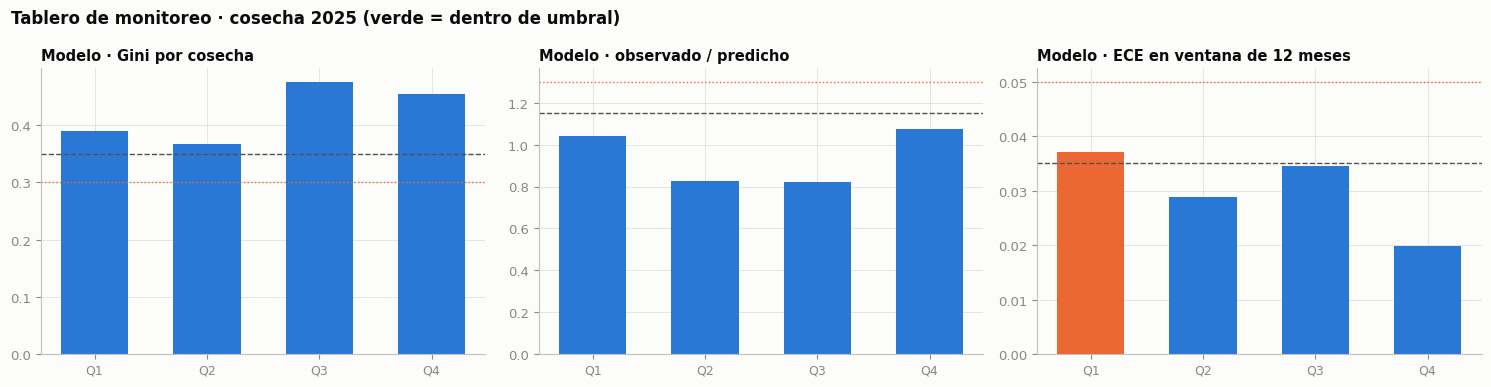

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
paneles = [("gini", "Modelo · Gini por cosecha", 0.35, 0.30, "min"),
           ("observado_sobre_predicho", "Modelo · observado / predicho", 1.15, 1.30, "max"),
           ("ece_movil_12m", "Modelo · ECE en ventana de 12 meses", 0.035, 0.05, "max")]
for ax, (col, titulo, verde, ambar, direccion) in zip(axes, paneles):
    valores = metricas[col]
    indicador = {"gini": "Gini de la cosecha", "observado_sobre_predicho": "Observado / predicho",
                 "ece_movil_12m": "Error de calibración (ECE, ventana 12 meses)"}[col]
    paleta = {"Verde": BLUE, "Ámbar": ORANGE, "Rojo": "#c0392b", "Sin dato": MUTED}
    colores = [paleta[mon.semaforo(indicador, v)] for v in valores]
    ax.bar(range(len(valores)), valores, color=colores, width=0.6)
    ax.axhline(verde, color=INK_2, lw=1, ls="--")
    ax.axhline(ambar, color=ORANGE, lw=1, ls=":")
    ax.set_xticks(range(len(valores)), [c_.replace("2025", "") for c_ in metricas.index], fontsize=9)
    ax.set_title(titulo, fontsize=10.5)
fig.suptitle("Tablero de monitoreo · cosecha 2025 (verde = dentro de umbral)", x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout(); savefig(fig, "fig35_monitoreo"); plt.show()

In [14]:
kpis = {"Cosechas monitoreadas": len(metricas), "Gini medio": f"{metricas['gini'].mean():.3f}",
        "Observado/predicho medio": f"{metricas['observado_sobre_predicho'].mean():.2f}",
        "PSI del score (máx.)": f"{metricas['psi_score'].max():.3f}",
        "Cola de revisión": f"{metricas['revision'].mean():.1%}",
        "EL / monto": f"{el_rate:.2%}", "Indicadores en alerta": len(acciones)}
ruta = pf.build_dashboard(cfg.REPORTS / "dashboard_monitoreo.html",
                          "Tablero de monitoreo · Caja Rural 360 (cosecha 2025)", kpis,
                          {"Indicadores por cosecha": metricas.round(4), "Semáforo": estado,
                           "Acciones ante alerta": acciones, "Umbrales y acciones": umbrales,
                           "Calendario de monitoreo": mon.calendario()},
                          [cfg.FIGURES / "fig35_monitoreo.png"],
                          "Datos, modelo y negocio se monitorean por separado. Los umbrales salen de lo medido en "
                          "6.7, 6.9 y 6.12; el Gini verde (0.35) es el piso de la banda histórica entre cosechas.")
print("Tablero de monitoreo:", Path(ruta).relative_to(cfg.ROOT))

Tablero de monitoreo: reports/dashboard_monitoreo.html


**Lectura del tablero.** Con la cosecha 2025 cerrada y el calibrador ajustado en VAL, el modelo queda en verde en datos y en discriminación: PSI del score por debajo de 0.01 en los cuatro trimestres y Gini entre 0.35 y 0.50. Los indicadores que se encienden son los esperables y ya documentados: la **cola de revisión** por encima del 20% (hallazgo V-05) y el **default de la cosecha** en dos trimestres, que es justo el escenario para el que existe el disparador de recalibración.

**Un umbral que hubo que corregir.** La primera versión medía el error de calibración (ECE) por trimestre con umbral 0.03 y encendía rojo dos veces. La simulación de arriba muestra por qué era un falso positivo: con cosechas de ~300 créditos, una calibración **perfecta** ya produce un ECE mediano de 0.046. El indicador pasó a medirse sobre **ventana móvil de 12 meses** (~1,200 créditos, ECE esperado 0.023) con umbral verde en 0.035. Es el tipo de umbral que hay que calibrar con simulación y no con una convención, o el tablero termina enseñando a ignorar alertas.

Lo importante no es que todo esté verde, sino que **cada alerta tiene una acción asignada y un responsable**, y que las acciones están ordenadas: primero calibración, después corte, y solo al final reentrenamiento.

| Requisito | Dónde |
|---|---|
| 6.14 · Model Card del champion y fichas de EAD y LGD | §3 · `models/model_card_scorecard_pd.md`, `ficha_ead.md`, `ficha_lgd.md` |
| 6.14 · Inventario, roles, ciclo de vida y tres líneas de defensa | §1 y §2 · `gobierno_inventario.csv`, `gobierno_ciclo_de_vida.csv` |
| 6.14 · Materialidad y frecuencia de revisión | §1 · `gobierno_materialidad.csv` |
| 6.14 · Validación independiente con 5+ hallazgos y plan de remediación | §4 · `reports/independent_validation_report.md` (10 hallazgos) |
| 6.14 · Checklist de auditoría y evidencia de reproducibilidad | §5 · `gobierno_checklist_auditoria.csv` |
| 6.15 · Tablero con drift, performance, calibración, cartera y operación | §6 a §8 · `reports/dashboard_monitoreo.html` · `fig35` |
| 6.15 · Umbrales Verde/Ámbar/Rojo | §6 · `monitoreo_umbrales.csv` |
| 6.15 · Acción ante cada alerta | §6 y §7 · `monitoreo_acciones.csv` |
| 6.15 · Separar monitoreo de datos, de modelo y de negocio | §6 · columna `tipo` en todas las tablas |